In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph.message import add_messages

In [2]:
load_dotenv()  # Load environment variables from .env file
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [3]:
from typing import Annotated
class ChatState(MessagesState):
    summary: Annotated[str, "A summary of the old messages so far."]

In [ ]:
from langchain_classic.prompts import MessagesPlaceholder


chat_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant."
    ),
    MessagesPlaceholder(variable_name="messages"),
    ])

In [12]:
summarize_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant."
    ),
    MessagesPlaceholder(variable_name="messages"),
    (
        "system",
        "Summarize the conversation so far in pointers. "
        "The summary should be concise and capture the main points of the conversation."
    ),
])

In [ ]:
def summarize_conversation(state: ChatState):
    existing_summary = state.get("summary", "")
    messages = state["messages"]
    if existing_summary:
        messages = [{"role": "system", "content": f"Existing summary: {existing_summary}"}] + messages
    
    if len(messages) < 6:
        return {}
    
    summary_chain = summarize_prompt_template | llm
    summary = summary_chain.invoke({"messages": messages})
    
    deleted_messages = state["messages"][:-2]  # Delete all but the last two messages
    
    return {
        "summary": summary.text,
        "messages": [RemoveMessage(id=msg.id) for msg in deleted_messages],  # Keep only the last two messages
    }

In [5]:
def chat_node(state: ChatState):
    messages = []
    if state['summary']:
        messages.append({"role": "system", "content": f"Summary of previous messages: {state['summary']}"})
    messages.extend(state["messages"])
    chain = prompt_template | llm
    response = chain.invoke({"messages": messages})
    
    return {"messages": [response]}

In [ ]:
from langgraph.graph.message import RemoveMessage

def delete_old_messages(state: ChatState):
    messages = state["messages"]
    # Keep only the last 5 messages
    if len(messages) > 10:
        to_remove = messages[:6] 
        return {"messages": [RemoveMessage(id=msg.id) for msg in to_remove]}
    return {}

In [7]:
graph = StateGraph(ChatState)
#add nodes
graph.add_node('chat_node', chat_node)
graph.add_node('delete_old_messages', delete_old_messages)

In [8]:
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', 'delete_old_messages')
graph.add_edge('delete_old_messages', END)

In [10]:
from langgraph.checkpoint.memory import MemorySaver

config_t2 = {"configurable" : {"thread_id" :  "deletion_summarization_thread"}}
workflow = graph.compile(checkpointer = MemorySaver())

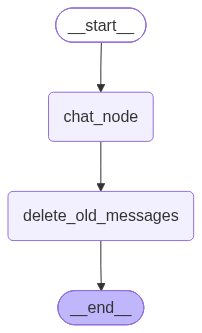

In [11]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))